In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import astropy.io.fits as fits
import scipy
import healpy as hp
import math
import requests
import astropy.units as u
import glob
from scipy.optimize import fsolve

In [14]:
data_file = '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/20240918_210655983_Bias.fits'

In [16]:
# hdu - header data unit
hdulist = fits.open(data_file)

# gives you the information about your fits file - indexing starts at zero
# 51 cards = 51 different oieces of information about the image
# images are stored as pixels and each pixel is stored in the form of integers
hdulist.info()

Filename: /Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/20240918_210655983_Bias.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      51   (1663, 1252)   int16 (rescales to uint16)   


In [18]:
# repr() stands for representation and it makes the headers look pretty and easier to read
print(repr(hdulist[0].header))

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 1663 / length of data axis 1                          
NAXIS2  =                 1252 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
BZERO   =                32768 / offset data range to that of unsigned short    
BSCALE  =                    1 / default scaling factor                         
ROWORDER= 'TOP-DOWN'           / Order of the rows in image array               
INSTRUME= 'Apogee F8300 CCD'   / Instrument used for acquisition                
TELESCOP= 'Linda Sue 16-inch

In [20]:
# converting unsigned integers to floats using astype(float)
image = hdulist[0].data.astype(float)

In [22]:
# tells you how big the image is (y,x)
print(image.shape)

(1252, 1663)


In [24]:
# mean value of my image
np.mean(image)

1317.3607087349358

In [26]:
# standard deviation of my image
np.std(image)

13.315856847290974

In [28]:
halfimage = image / 2.0
print(np.mean(halfimage))

658.6803543674679


In [32]:
hdulist.close()

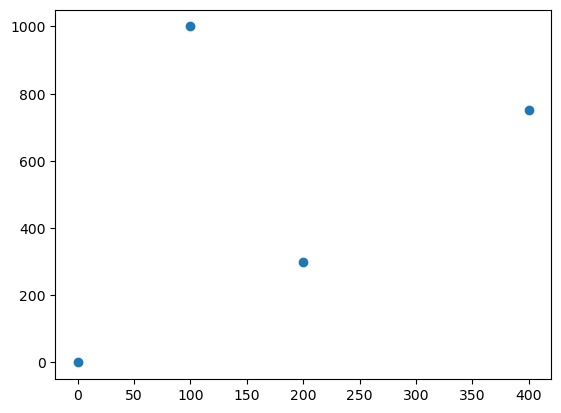

In [34]:
fig, ax = plt.subplots()

x = [0, 100, 200, 400]
y = [0, 1000, 300, 750]

ax.scatter(x,y)

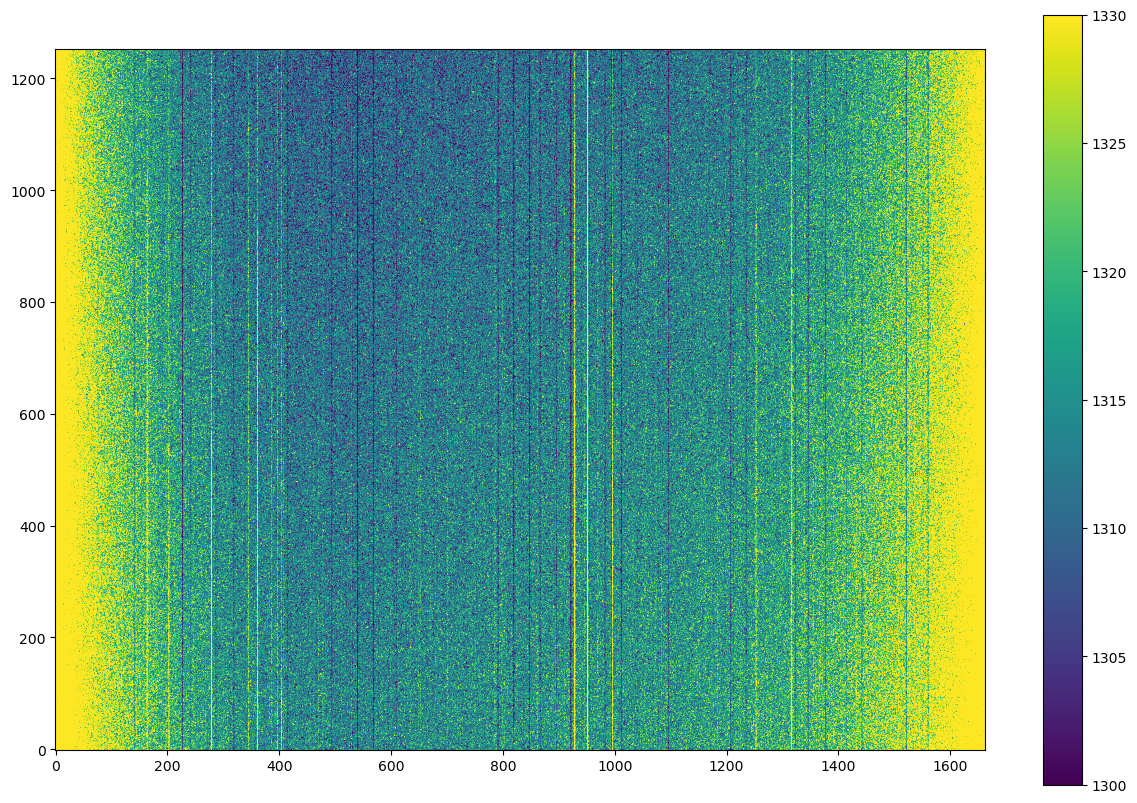

In [36]:
fig , ax = plt.subplots(figsize = (15, 10))
# showing the image
# vmin, vmax = mean +- std we found earlier
# cmap = pyplot color maps
cb = ax.imshow(image, vmin = 1300, vmax = 1330, origin = 'lower', cmap = 'viridis')
# colorbar shows the color strip on the right
fig.colorbar(cb)

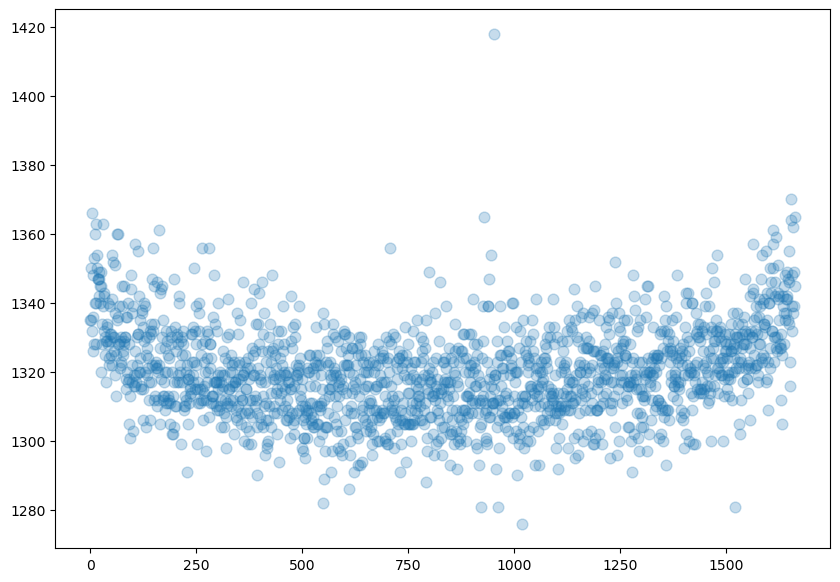

In [38]:
# chose one row from the plot above

fig, ax = plt.subplots(figsize = (10, 7))

x_coords = np.arange(image.shape[1])
y_vals = image[50, :]
# s (size) - tells you how many square pixels is one point
ax.scatter(x_coords, y_vals, s = 60, alpha = 0.25)

In [40]:
# averaging columnwise or rowwise

# averaged along the y direction or the y axis
average_profile = np.mean(image, axis = 0)
print(average_profile.shape)

(1663,)


In [42]:
median_profile = np.median(image, axis = 0)

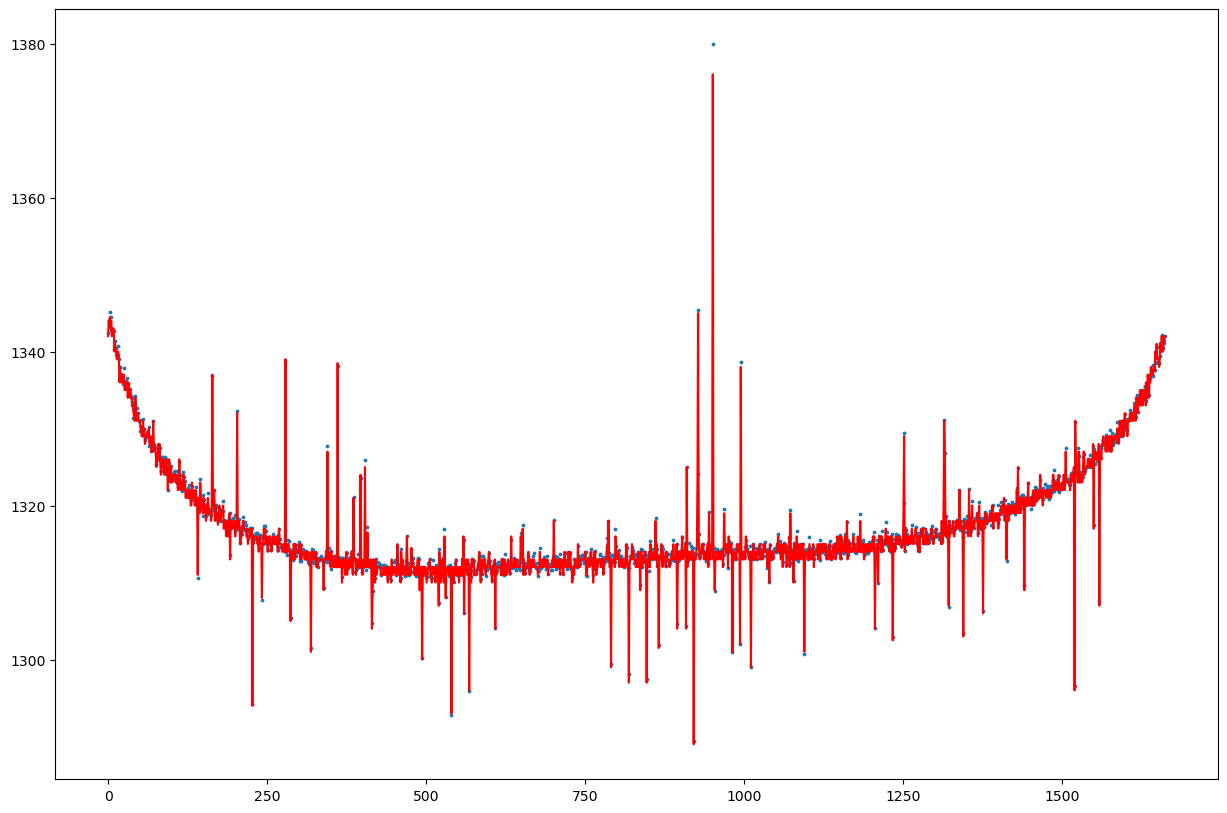

In [44]:
fig, ax = plt.subplots(figsize = (15, 10))
ax.scatter(x_coords, average_profile, s = 3)
ax.plot(x_coords, median_profile, c = 'red')

(array([0.00000e+00, 0.00000e+00, 9.00000e+00, 3.90000e+01, 2.30000e+02,
        1.02400e+03, 4.40500e+03, 1.40630e+04, 4.12210e+04, 9.33020e+04,
        1.74037e+05, 2.67092e+05, 3.09697e+05, 3.29569e+05, 2.80745e+05,
        2.14666e+05, 1.43939e+05, 9.06040e+04, 5.38100e+04, 3.13560e+04,
        1.58800e+04, 8.50500e+03, 4.08700e+03, 1.86800e+03, 8.77000e+02,
        4.11000e+02, 2.32000e+02, 1.52000e+02, 8.20000e+01, 5.40000e+01]),
 array([1250., 1255., 1260., 1265., 1270., 1275., 1280., 1285., 1290.,
        1295., 1300., 1305., 1310., 1315., 1320., 1325., 1330., 1335.,
        1340., 1345., 1350., 1355., 1360., 1365., 1370., 1375., 1380.,
        1385., 1390., 1395., 1400.]),
 <BarContainer object of 30 artists>)

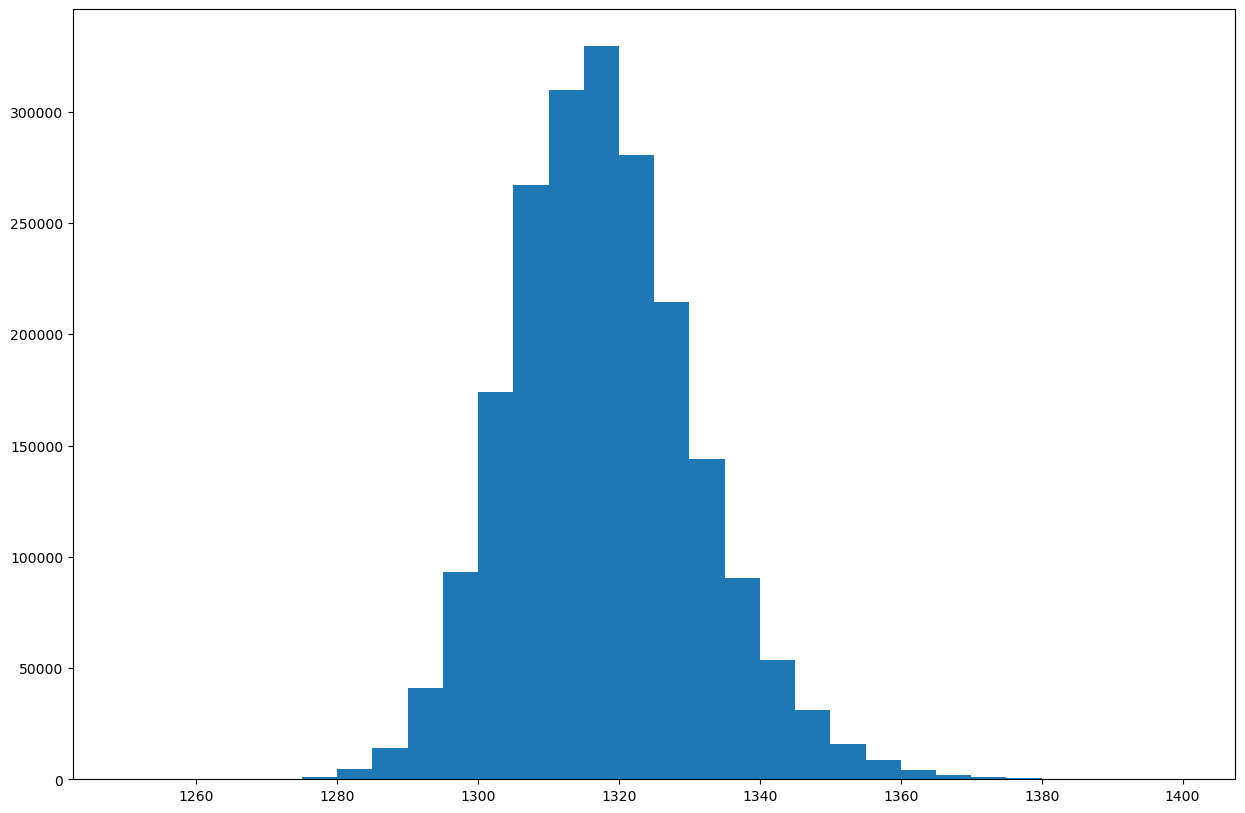

In [46]:
fig, ax = plt.subplots(figsize = (15, 10))
# flatten should also work
ax.hist(image.ravel(), range = (1250, 1400), bins = 30)
# ax.vline(np.median(image[1250:1400]))
# ax.set_yscale('log')

# Starting with the actual optical lab analysis

## part 1

In [50]:
plate_scale = 0.27846 # arcseconds
field_of_view_x = 3326 * 0.27846
field_of_view_y = 2504 * 0.27846

print(field_of_view_x)
print(field_of_view_y)
print("Field of view is", f"{round(field_of_view_x)} x {round(field_of_view_y)}")

926.15796
697.26384
Field of view is 926 x 697


## part 2

In [62]:
bias_files_path = '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/'

bias_files_names = sorted(os.listdir(bias_files_path))
bias_file = []
for file_name in bias_files_names:
    bias_file.append(bias_files_path + file_name)
bias_file

['/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004013588_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004018153_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004022617_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004027089_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004031645_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004036204_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004040660_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004045118_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_004049578_Bias.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/riya_bias/20240923_00

In [64]:
def make_image(file_name, vmin = None, vmax = None, show = False, flats = True):
    hdulist = fits.open(file_name)
    image = hdulist[0].data.astype(float)
    # finding std across y axis
    
    if show == True and flats == True:
        fig, ax = plt.subplots(figsize = (15,10))
        cb = ax.imshow(image, vmin = np.mean(image) - np.std(image), vmax = np.mean(image) + np.std(image),
                      origin = 'lower', cmap = 'viridis')
        fig.colorbar(cb)
        plt.show()
        
    if show == True and flats == False:
        fig , ax = plt.subplots(figsize = (15, 10))
        cb = ax.imshow(image, vmin = vmin, vmax = vmax, origin = 'lower', cmap = 'viridis')
        fig.colorbar(cb)
        plt.show()
    
    return image

## part 3

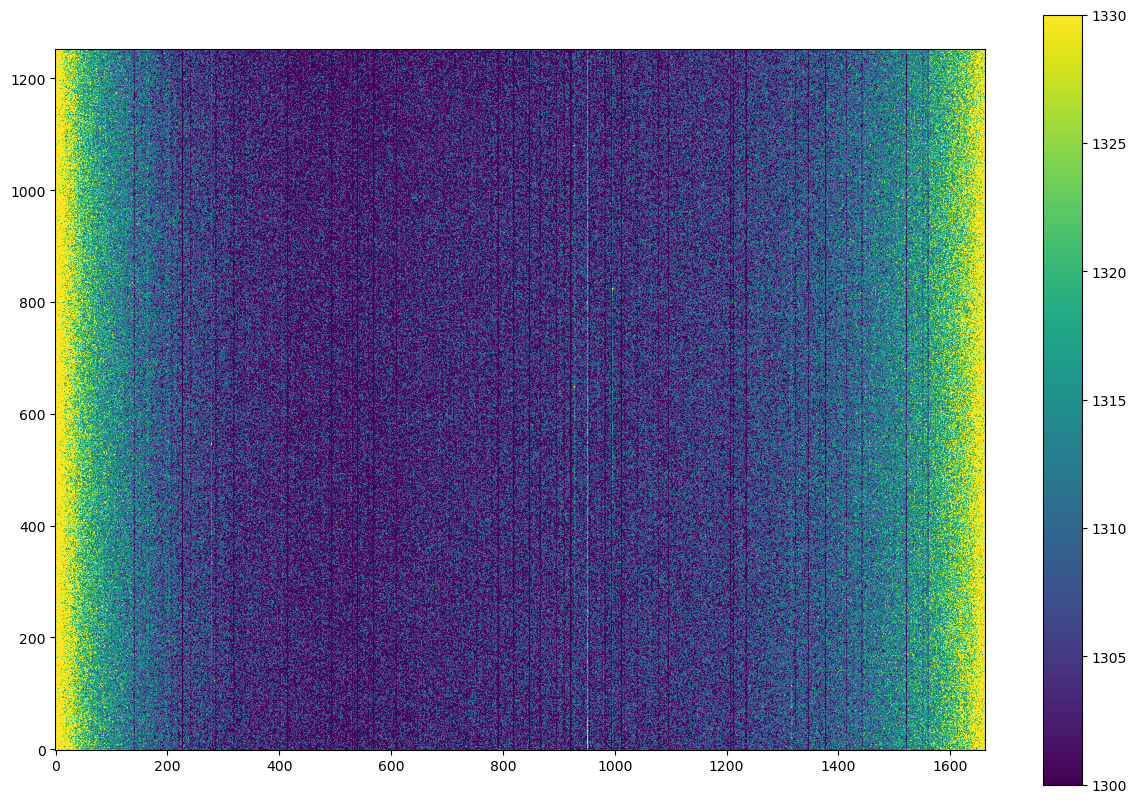

In [159]:
bias_images = []
for i, file in enumerate(bias_file):
    if i == 1 | i == 2 | i == 3:
        image = make_image(file, 1300, 1330, show = True, flats = False)
    else:
        image = make_image(file, 1300, 1330, show = False, flats = False)
    bias_images.append(image)

In [155]:
readnoise = np.mean(np.std(bias_images, axis = 0))
readnoise

9.904889547519621

## part 4

In [117]:
flat1 = []
flat2 = []
flat10 = []

for file in glob.glob('new_flats/*r_1s_1x1.fits'):
    flat1.append(fits.open(file)[0].data.astype(float))

for file in glob.glob('new_flats/*r_2s_1x1.fits'):
    flat2.append(fits.open(file)[0].data.astype(float))

for file in glob.glob('new_flats/*r_10s_1x1.fits'):
    flat10.append(fits.open(file)[0].data.astype(float))

In [119]:
flat1_noise, flat1_diff = np.mean(np.mean(flat1,axis=0)), np.std(flat1[0] - flat1[1])
flat2_noise, flat2_diff = np.mean(np.mean(flat2,axis=0)), np.std(flat2[0] - flat2[1])
flat10_noise, flat10_diff = np.mean(np.mean(flat10,axis=0)), np.std(flat10[0] - flat10[1])

## part 5

In [122]:
# choose any two random biases for analysis
bias_1_img = bias_images[0]
bias_2_img = bias_images[1]

# avg_bias = np.mean(np.sum([bias_1_img,bias_2_img]))
avg_bias_img = np.mean(np.sum([bias_1_img,bias_2_img ], axis = 0))
bias_std = np.std(bias_1_img - bias_2_img)

In [124]:
avg_bias_img

2618.0386426816312

In [126]:
def func(avg_flat_noise, avg_bias_img, flats_std, bias_std):
    return (avg_flat_noise - avg_bias_img) / ((flats_std)**2 - (bias_std)**2)

In [128]:
gain1 = func(np.mean(np.sum(flat1, axis = 0)), avg_bias_img, flat1_diff, bias_std)
gain2 = func(np.mean(np.sum(flat2, axis = 0)), avg_bias_img, flat2_diff, bias_std)
gain10 = func(np.mean(np.sum(flat10, axis = 0)), avg_bias_img, flat10_diff, bias_std)
print(gain1, gain2, gain10)

0.9768901170109029 0.9836314209130912 1.057000794483817


## part 6

Theoretical Gain:

$ \sigma (I[e^{-}]) = \sqrt{I + \sigma^{2}_{readnoise[e^{-}]}} $

In [132]:
def theory_gainfunc(gain, sigmaI, meanI, readnoise = readnoise):
    return sigmaI - (1 / gain) * np.sqrt(meanI * (gain) + readnoise**2)

/var/folders/w1/x9k0hbvs5g79qr0pty3j8x6c0000gn/T/ipykernel_80884/1321170107.py:2: RuntimeWarning: invalid value encountered in sqrt
  return sigmaI - (1 / gain) * np.sqrt(meanI * (gain) + readnoise**2)
/var/folders/w1/x9k0hbvs5g79qr0pty3j8x6c0000gn/T/ipykernel_80884/1104308231.py:8: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  theory_gain = fsolve(theory_gainfunc,1, args=(np.std(I),np.mean(I)))[0]


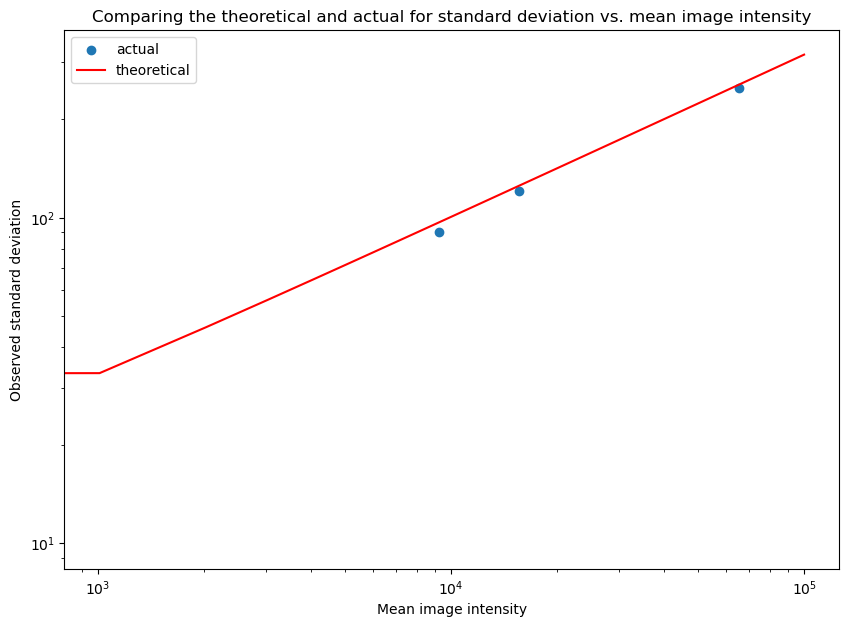

In [134]:
I  = np.array([np.mean(np.sum(flat1,axis=0)), np.mean(np.sum(flat2,axis=0)), np.mean(np.sum(flat10,axis=0))])
sigma = np.array([flat1_diff, flat2_diff, flat10_diff])
var = np.sqrt(I + sigma**2)

theory_I = np.linspace(0,100000,100)
theory_var = np.sqrt(theory_I + readnoise**2)

theory_gain = fsolve(theory_gainfunc,1, args=(np.std(I),np.mean(I)))[0]

fig,ax = plt.subplots(figsize = (10,7))

# actual
ax.scatter(I, var/np.sqrt(2), label = 'actual')

# theoretical
ax.plot(theory_I, theory_var, color='red', label = 'theoretical')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Comparing the theoretical and actual for standard deviation vs. mean image intensity')
ax.set_xlabel('Mean image intensity')
ax.set_ylabel('Observed standard deviation')
ax.legend()
plt.show()

## part 7

In [137]:
hot_pixels1 = len(np.where(np.mean(flat1,axis=0) > 1.2*np.mean(np.mean(flat1,axis=0)))[0])
hot_pixels2 = len(np.where(np.mean(flat2,axis=0) > 1.2*np.mean(np.mean(flat2,axis=0)))[0])
hot_pixels10 = len(np.where(np.mean(flat10,axis=0) > 1.2*np.mean(np.mean(flat10,axis=0)))[0])

cold_pixels1 = len(np.where(np.mean(flat1,axis=0) < 0.8*np.mean(np.mean(flat1,axis=0)))[0])
cold_pixels2 = len(np.where(np.mean(flat2,axis=0) < 0.8*np.mean(np.mean(flat2,axis=0)))[0])
cold_pixels10 = len(np.where(np.mean(flat10,axis=0) < 0.8*np.mean(np.mean(flat10,axis=0)))[0])

print(f"For 1s exposure time, we have {hot_pixels1} hot pixels and {cold_pixels1} cold pixel(s)")
print(f"For 2s exposure time, we have {hot_pixels2} hot pixels and {cold_pixels2} cold pixel(s)")
print(f"For 10s exposure time, we have {hot_pixels10} hot pixels and {cold_pixels10} cold pixel(s)")

For 1s exposure time, we have 37 hot pixels and 1 cold pixel(s)
For 2s exposure time, we have 40 hot pixels and 1 cold pixel(s)
For 10s exposure time, we have 33 hot pixels and 2 cold pixel(s)


## part 8

In [140]:
flats_files_path = '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/'

flats_files_names = sorted(os.listdir(flats_files_path))
flats_file = []
for file_name in flats_files_names:
    if 'r' in file_name:
        flats_file.append(flats_files_path + file_name)
flats_file

['/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_221827_Flat_r_1s_1x1.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_221928_Flat_r_1s_1x1.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_222018_Flat_r_2s_1x1.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_222034_Flat_r_2s_1x1.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_222139_Flat_r_10s_1x1.fits',
 '/Users/riyakore/Desktop/Astronomy/Astron_465/Optical Lab 1/new_flats/20241001_222204_Flat_r_10s_1x1.fits']

In [142]:
for file in flats_file:
    image = make_image(file, show = False, flats = True)

## part 9

In [145]:
flatr, flatg, flati = [], [], []
for file in glob.glob('new_flats/*g_2s_1x1.fits'):
    flatg.append(fits.open(file)[0].data.astype(float))

for file in glob.glob('new_flats/20241001_222018_Flat_r_2s_1x1.fits'):
    flatr.append(fits.open(file)[0].data.astype(float))

for file in glob.glob('new_flats/*i_2s_1x1.fits'):
    flati.append(fits.open(file)[0].data.astype(float))

g band


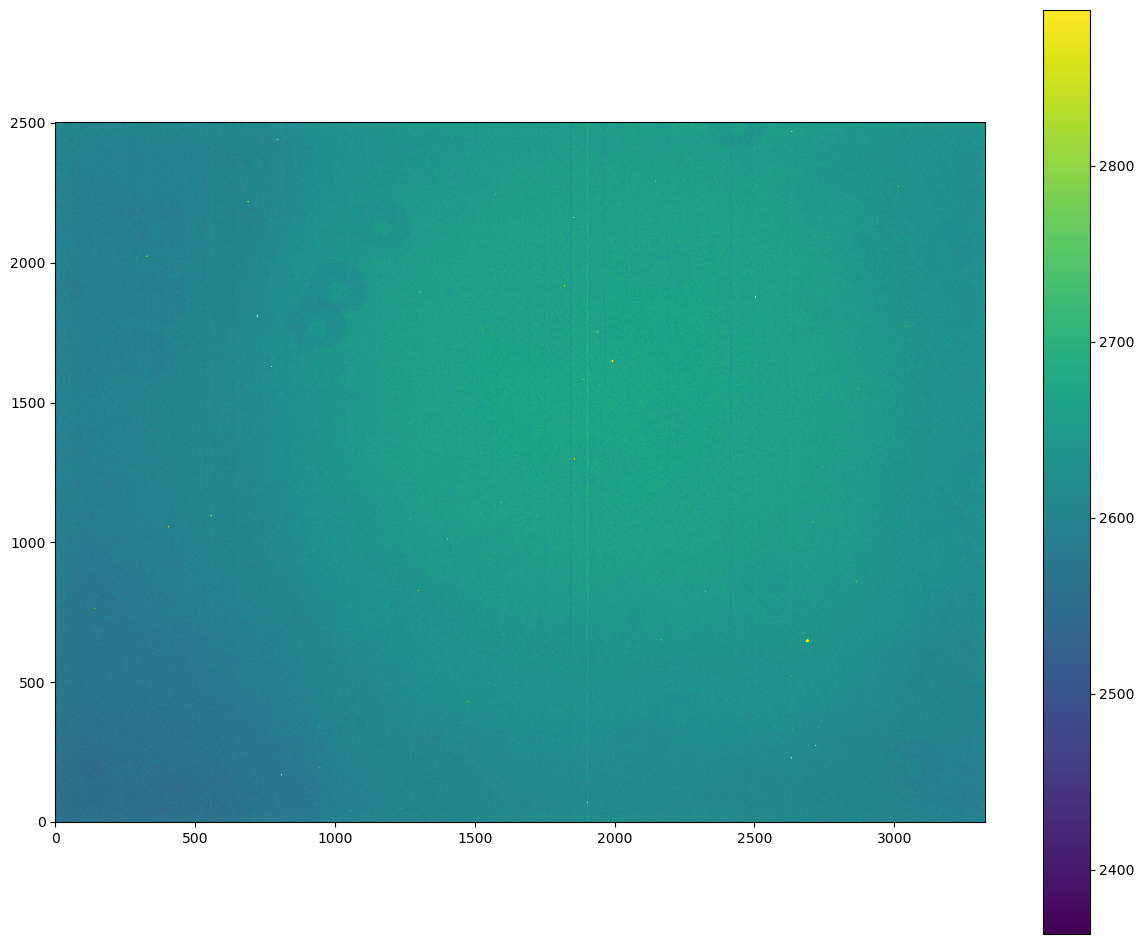

In [147]:
# g band

print("g band")
fig, ax = plt.subplots(figsize=(15,12))
vmin = np.mean(np.mean(flatg,axis=0)) - 3*np.mean(np.std(flatg, axis=0))
vmax = np.mean(np.mean(flatg,axis=0)) + 3*np.mean(np.std(flatg, axis=0))
cb = ax.imshow(flatg[0],vmin=vmin,vmax=vmax)
fig.colorbar(cb)
ax.invert_yaxis()

r band


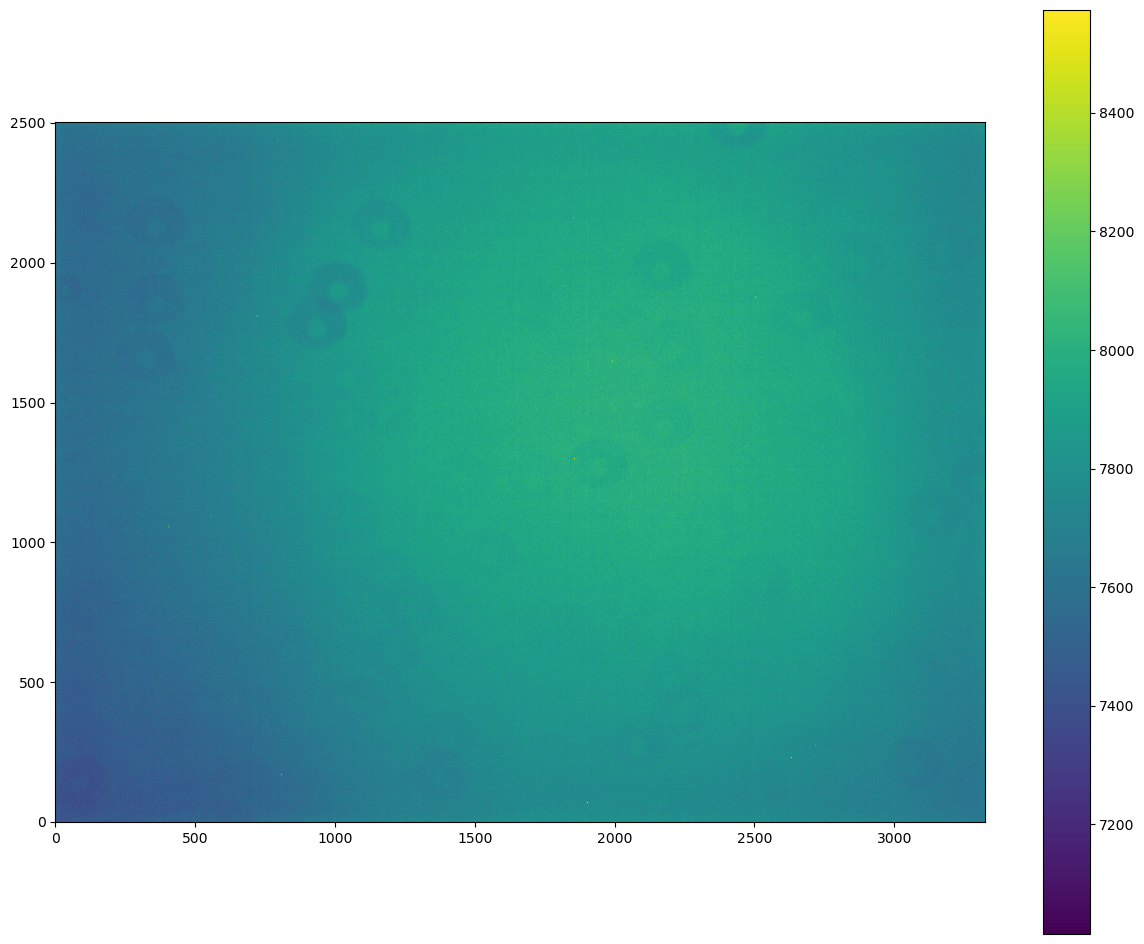

In [149]:
# r band

print("r band")
fig, ax = plt.subplots(figsize=(15,12))
vmin = np.mean(np.mean(flatr,axis=0)) - 3*np.mean(np.std(flatr, axis=0))
vmax = np.mean(np.mean(flatr,axis=0)) + 3*np.mean(np.std(flatr, axis=0))
cb = ax.imshow(flatr[0],vmin=vmin,vmax=vmax)
fig.colorbar(cb)
ax.invert_yaxis()
plt.show()

i band


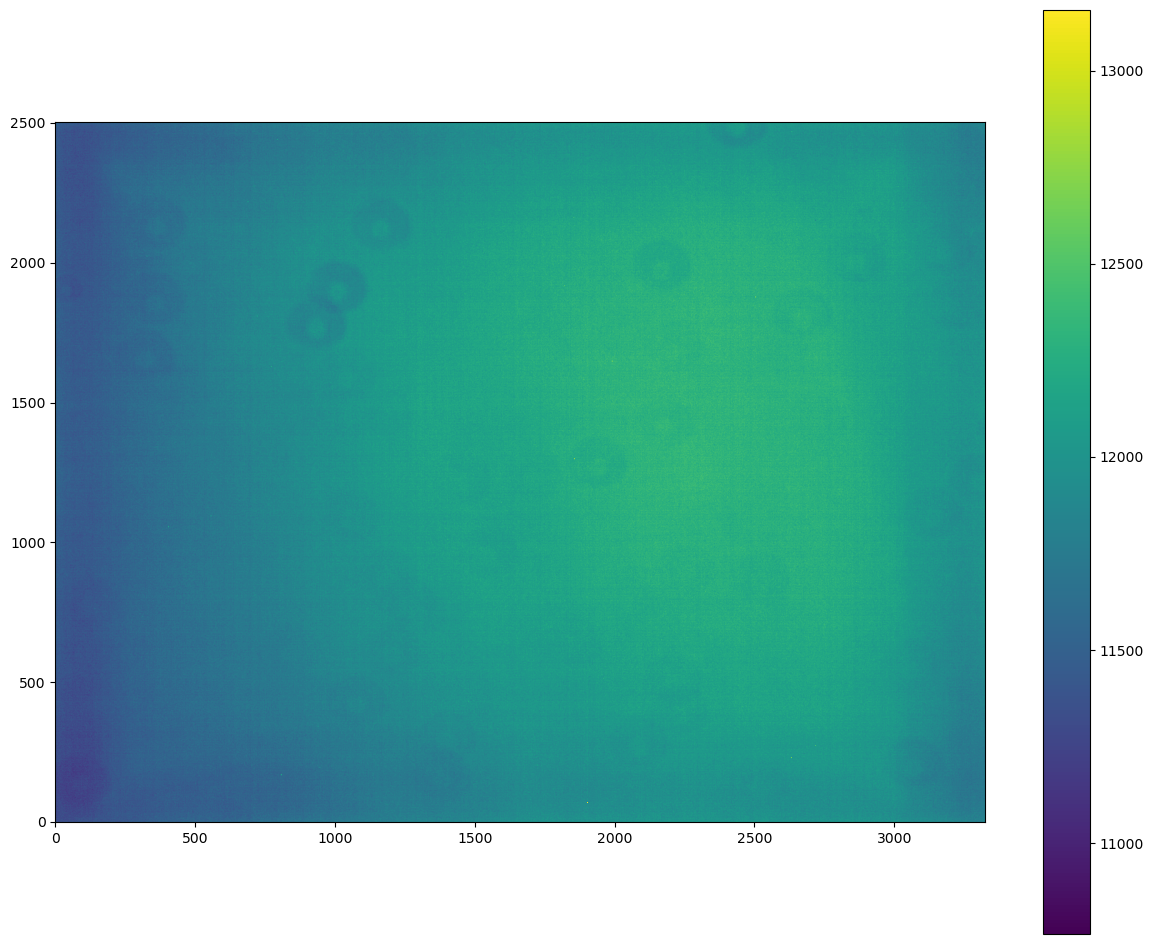

In [150]:
# i band

print("i band")
fig, ax = plt.subplots(figsize=(15,12))
vmin = np.mean(np.mean(flati,axis=0)) - 3*np.mean(np.std(flati, axis=0))
vmax = np.mean(np.mean(flati,axis=0)) + 3*np.mean(np.std(flati, axis=0))
cb = ax.imshow(flati[0],vmin=vmin,vmax=vmax)
fig.colorbar(cb)
ax.invert_yaxis()
plt.show()